In [1]:
pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.9 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=0c52a7fbd95e0d4eaa685691f3d675ef994549e1037111d8af3067b996579191
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [16]:
import pretty_midi
import os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now that your Google Drive is mounted, you can define the path to your subfolder. I will assume `AAI590_FinalProject` is directly under `MyDrive` for this example. If it's located elsewhere (e.g., under `Colab Notebooks`), you'll need to adjust the `subfolder_path` accordingly.

Based on your file list, there is a directory named `/content/drive/MyDrive/Colab Notebooks/MSAAI521_FinalProject/`. If `AAI590_FinalProject` was a typo and you meant `MSAAI521_FinalProject`, please adjust the `subfolder_path` variable below.

In [4]:
# Define the path to the subfolder
project_directory = '/content/drive/MyDrive/AAI590_FinalProject'

# Check if the directory exists
if os.path.exists(project_directory):
    print(f"Accessing: {project_directory}")
    # Change the current working directory to the subfolder
    os.chdir(project_directory)
    print(f"Current working directory: {os.getcwd()}")
    print("Contents of the subfolder:")
    # List the contents of the subfolder
    for item in os.listdir(project_directory):
        print(item)
else:
    print(f"The directory '{project_directory}' does not exist. Please check the path and try again.")
    print("You might have intended to access '/content/drive/MyDrive/Colab Notebooks/MSAAI521_FinalProject/' based on available files.")

Accessing: /content/drive/MyDrive/AAI590_FinalProject
Current working directory: /content/drive/MyDrive/AAI590_FinalProject
Contents of the subfolder:
590-Classical-music-midi
TestingSamples


In [5]:
from pathlib import Path

# Setting file system variables
midi_directory = f"{project_directory}/590-Classical-music-midi"
testing_directory = f"{project_directory}/TestingSamples"

print("Project directory:", project_directory)
print("MIDI directory:", midi_directory)
print("Exists:", Path(midi_directory).exists())

Project directory: /content/drive/MyDrive/AAI590_FinalProject
MIDI directory: /content/drive/MyDrive/AAI590_FinalProject/590-Classical-music-midi
Exists: True


In [13]:
def load_midi_file(file_path: str, fs: int = 100) -> tuple[pretty_midi.PrettyMIDI | None, float | None, pretty_midi.TimeSignature | None, int]:
    """
    Loads a MIDI file from the given file path and returns its PrettyMIDI object,
    initial tempo, time signature, and the frames per second (fs) used for piano roll calculation.

    Args:
        file_path (str): The path to the MIDI file.
        fs (int): Frames per second to use for piano roll calculation (default: 100).

    Returns:
        tuple[pretty_midi.PrettyMIDI | None, float | None, pretty_midi.TimeSignature | None, int]:
            A tuple containing:
            - pretty_midi.PrettyMIDI object if successful, None otherwise.
            - Initial tempo of the MIDI file (float) if successful, None otherwise.
            - Initial time signature of the MIDI file (pretty_midi.TimeSignature) if successful, None otherwise.
            - Frames per second (fs) used for piano roll.
    """
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return None, None, None, fs # Return None for midi_data, tempo, and time_signature, but fs value

    try:
        midi_data = pretty_midi.PrettyMIDI(file_path)
        print(f"Successfully loaded MIDI file: {file_path}")

        tempo_times, tempos = midi_data.get_tempo_changes()
        print(f"Tempo changes loaded correctly")

        if(tempos.size > 0):
            print(f"Initial tempo: {tempos[0]}")
            initial_tempo = tempos[0]
        else:
            print(f"No tempo changes found in the MIDI file")
            initial_tempo = 120.0 # Default to 120 BPM if no tempo changes explicitly set
        #initial_tempo = tempos[0] if tempos else 120.0 # Default to 120 BPM if no tempo changes explicitly set
        print(f"Initial tempo selected correctly")

        initial_time_signature = midi_data.time_signature_changes[0] if midi_data.time_signature_changes else None
        print(f"Initial time signature loaded correctly")

        return midi_data, initial_tempo, initial_time_signature, fs
    except Exception as e:
        print(f"Error loading MIDI file {file_path}: {e}")
        return None, None, None, fs # Return None for midi_data, tempo, and time_signature, but fs value

In [7]:
def split_midi_by_measure(pm_data: pretty_midi.PrettyMIDI) -> list[pretty_midi.PrettyMIDI]:
    """
    Splits a PrettyMIDI object into a list of PrettyMIDI objects, one for each measure.
    Notes are adjusted to have start/end times relative to the beginning of their measure.

    Args:
        pm_data (pretty_midi.PrettyMIDI): The PrettyMIDI object to split.

    Returns:
        list[pretty_midi.PrettyMIDI]: A list of PrettyMIDI objects, each representing a measure.
    """
    measures = []
    downbeats = pm_data.get_downbeats()

    if not downbeats:
        print("No downbeats found. Returning original MIDI as a single measure.")
        return [pm_data]

    # Add an implicit end boundary if the last downbeat is not the very end of the piece
    end_time = max([note.end for instrument in pm_data.instruments for note in instrument.notes]) if pm_data.instruments else 0
    measure_boundaries = list(downbeats)
    if measure_boundaries[-1] < end_time:
        measure_boundaries.append(end_time)

    for i in range(len(measure_boundaries) - 1):
        measure_start_time = measure_boundaries[i]
        measure_end_time = measure_boundaries[i+1]

        # Create a new PrettyMIDI object for this measure
        measure_pm = pretty_midi.PrettyMIDI(resolution=pm_data.resolution)

        # Copy time signature and tempo map for the current measure if they fall within its bounds
        # This simplified approach assumes the first relevant time signature/tempo is representative.
        # A more robust solution would track changes throughout the measure.
        for ts in pm_data.time_signature_changes:
            if measure_start_time <= ts.time < measure_end_time:
                measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(ts.numerator, ts.denominator, 0)) # Set time to 0 for relative measure start
                break # Assuming one time signature per measure for simplicity
        if not measure_pm.time_signature_changes and pm_data.time_signature_changes:
             # If no explicit TS found in bounds, use the last one before measure start
             relevant_ts = [ts for ts in pm_data.time_signature_changes if ts.time <= measure_start_time]
             if relevant_ts:
                 last_ts = relevant_ts[-1]
                 measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(last_ts.numerator, last_ts.denominator, 0))
             else:
                measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(4, 4, 0)) # Default if nothing found
        elif not measure_pm.time_signature_changes:
            measure_pm.time_signature_changes.append(pretty_midi.TimeSignature(4, 4, 0)) # Default if no TS in original MIDI

        # Iterate through instruments and notes
        for original_instrument in pm_data.instruments:
            new_instrument = pretty_midi.Instrument(program=original_instrument.program,
                                                    is_drum=original_instrument.is_drum,
                                                    name=original_instrument.name)
            for note in original_instrument.notes:
                # Check if the note is within the current measure's boundaries
                # A note is considered in the measure if its start time is within the measure,
                # or if it starts before and extends into the measure.
                if (measure_start_time <= note.start < measure_end_time) or \
                   (note.start < measure_start_time and note.end > measure_start_time):

                    # Adjust note start and end times relative to the measure's start
                    relative_start = max(0.0, note.start - measure_start_time)
                    relative_end = note.end - measure_start_time

                    # Ensure the note doesn't extend beyond the measure's relative end
                    relative_end = min(relative_end, measure_end_time - measure_start_time)

                    # Only add note if it has a positive duration within the measure
                    if relative_end > relative_start:
                        new_note = pretty_midi.Note(
                            velocity=note.velocity,
                            pitch=note.pitch,
                            start=relative_start,
                            end=relative_end
                        )
                        new_instrument.notes.append(new_note)
            if new_instrument.notes:
                measure_pm.instruments.append(new_instrument)

        measures.append(measure_pm)

    return measures

In [8]:
def get_frame_first_note(midi_content, fs):
  #Get all note start times
  note_start_times = [note.start for instrument in midi_content.instruments for note in instrument.notes]
  #Get the first note time
  first_note_time = min(note_start_times)
  #Calculate the frame in which the note shows up
  first_frame = int(first_note_time * fs)
  #Return the first frame
  return first_frame
def midi_to_pianoroll(midi_path):
  # Load MIDI
  midi_data, initial_tempo, initial_time_signature, piano_roll_fs = load_midi_file(midi_path)
  if midi_data is None:
      return None, None
  # Get first frame with a note
  first_active_frame = get_frame_first_note(midi_data, piano_roll_fs)

  # Full piano roll, shape: (128, time)
  piano_roll = midi_data.get_piano_roll(fs=piano_roll_fs)
  piano_roll = piano_roll / 127.0  # Normalize velocity
  piano_roll = piano_roll[:, first_active_frame:]  # Trim leading silence
  piano_roll = piano_roll.T  # Now shape: (time, 128)

  # Clip to valid MIDI range
  piano_roll = piano_roll[:, :128]

  return piano_roll, piano_roll_fs
def plot_piano_roll(midi_path, title="Piano Roll", save_path=None):
  #First we obtain the piano roll based on the path
  piano_roll, fs = midi_to_pianoroll(midi_path)
  time_steps = piano_roll.shape[0] #Getting timesteps
  duration = time_steps / fs #Calculating duration
  time_axis = np.linspace(0, duration, time_steps) #Preparing time axis dimension
  print(f'Time Steps: {time_steps}, Frames per Second: {fs}, Duration: {duration:.2f}s')
  #Next, we plot the Piano Roll
  plt.figure(figsize=(12, 6))
  plt.imshow(piano_roll.T, aspect='auto', origin='lower',
              extent=[0, duration, 0, piano_roll.shape[1]], cmap='gray_r')
  plt.xlabel('Time (s)')
  plt.ylabel('MIDI Note')
  plt.title(title)
  plt.tight_layout()

  if save_path:
      plt.savefig(save_path)
  else:
      plt.show()


In [14]:
# Assuming a MIDI file exists in the testing_directory
example_midi_path = os.path.join(testing_directory, 'MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid')

# Call the function and capture the returned values
midi_data_obj, initial_tempo, initial_time_signature, piano_roll_fs = load_midi_file(example_midi_path, fs=100)

# Print the captured parameters
if midi_data_obj:
    print(f"\nMIDI Data Object: {midi_data_obj}")
    print(f"Initial Tempo: {initial_tempo} BPM")
    if initial_time_signature:
        print(f"Initial Time Signature: {initial_time_signature.numerator}/{initial_time_signature.denominator}")
    else:
        print("Initial Time Signature: Not found")
    print(f"Frames Per Second (fs) for Piano Roll: {piano_roll_fs}")
else:
    print("Failed to load MIDI file.")

Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/TestingSamples/MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid
Tempo changes loaded correctly
Initial tempo: 75.0
Initial tempo selected correctly
Initial time signature loaded correctly

MIDI Data Object: <pretty_midi.pretty_midi.PrettyMIDI object at 0x7e1f74942720>
Initial Tempo: 75.0 BPM
Initial Time Signature: 3/8
Frames Per Second (fs) for Piano Roll: 100


/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/590-Classical-music-midi/beeth/elise.mid
Tempo changes loaded correctly
Initial tempo: 69.17997516438892
Initial tempo selected correctly
Initial time signature loaded correctly
Time Steps: 16473, Frames per Second: 100, Duration: 164.73s


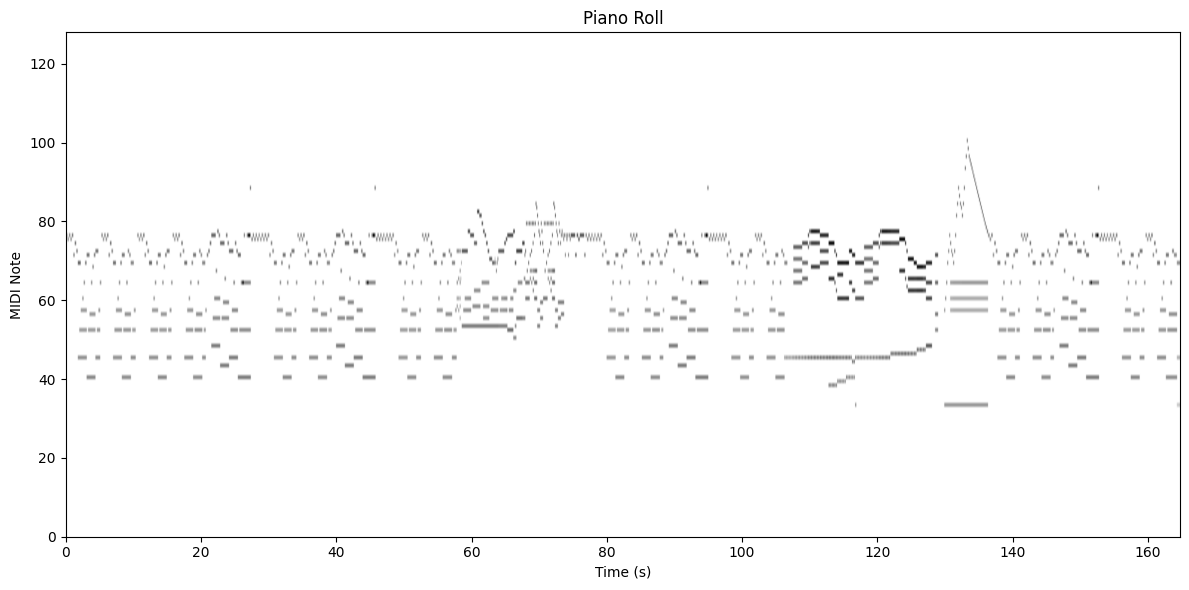

In [17]:
sample_path = f'{midi_directory}/beeth/elise.mid'
plot_piano_roll(sample_path)

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Successfully loaded MIDI file: /content/drive/MyDrive/AAI590_FinalProject/TestingSamples/MidiOutputs/Beethoven/Fur Elise_Full_K-Amin_T-variable_bothhands.mid
Tempo changes loaded correctly
Initial tempo: 75.0
Initial tempo selected correctly
Initial time signature loaded correctly
Time Steps: 15691, Frames per Second: 100, Duration: 156.91s


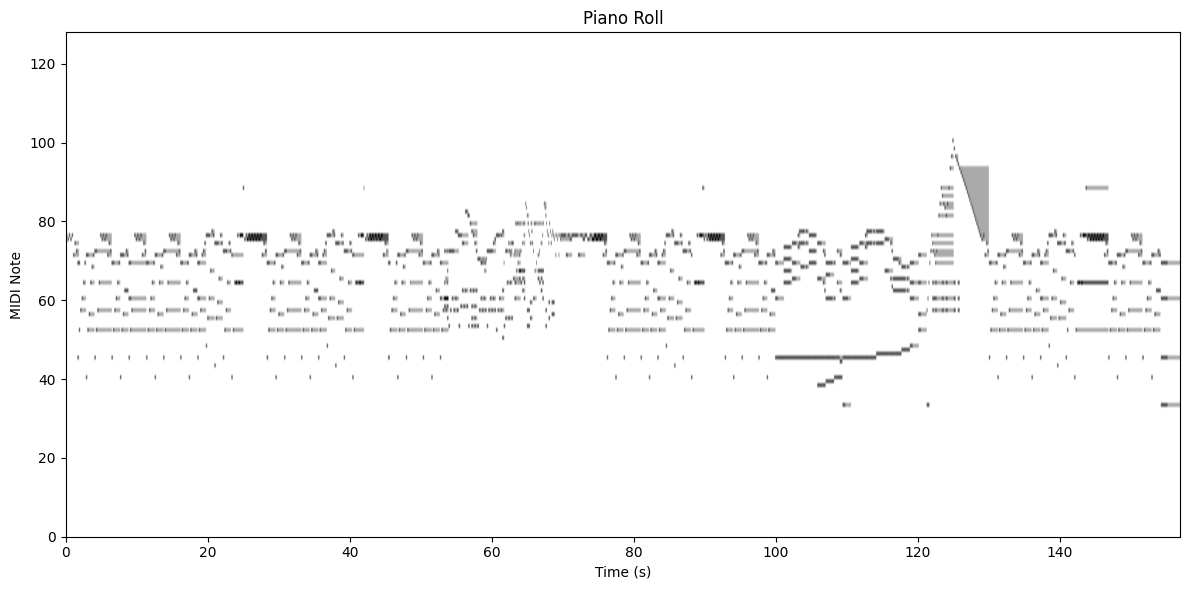

In [18]:
plot_piano_roll(example_midi_path)